### Drug Response Classification using SVM

In [53]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV

In [54]:
df = pd.read_csv("Pharma_Industry.csv")

In [55]:
# display no of rows & columns
df.shape

(500, 6)

In [56]:
# dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [57]:
# display missing values
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [58]:
# display first 5 rows
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [59]:
# statistical summary
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [60]:
# display datatypes of columns
df.dtypes

Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object

#### Data Preprocessing

In [61]:
# Encode categorical variables if any
df = pd.get_dummies(df, drop_first=True)

In [62]:
# Split features and target
X = df.drop("Drug Response", axis=1)
y = df["Drug Response"]


In [63]:
# Split train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#### Data Visualization

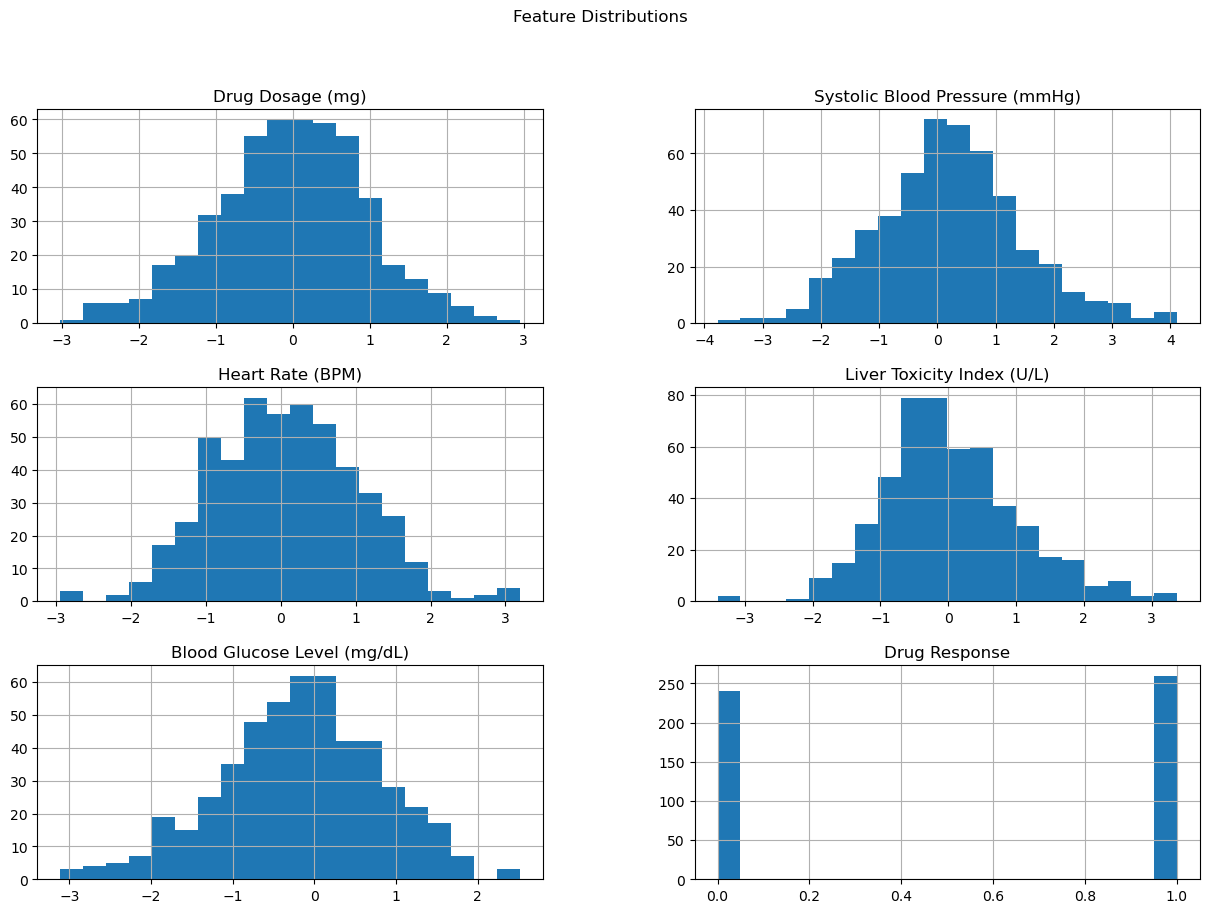

In [65]:
# Visualize distributions of numerical features
df.hist(bins=20, figsize=(15,10))
plt.suptitle("Feature Distributions")
plt.show()

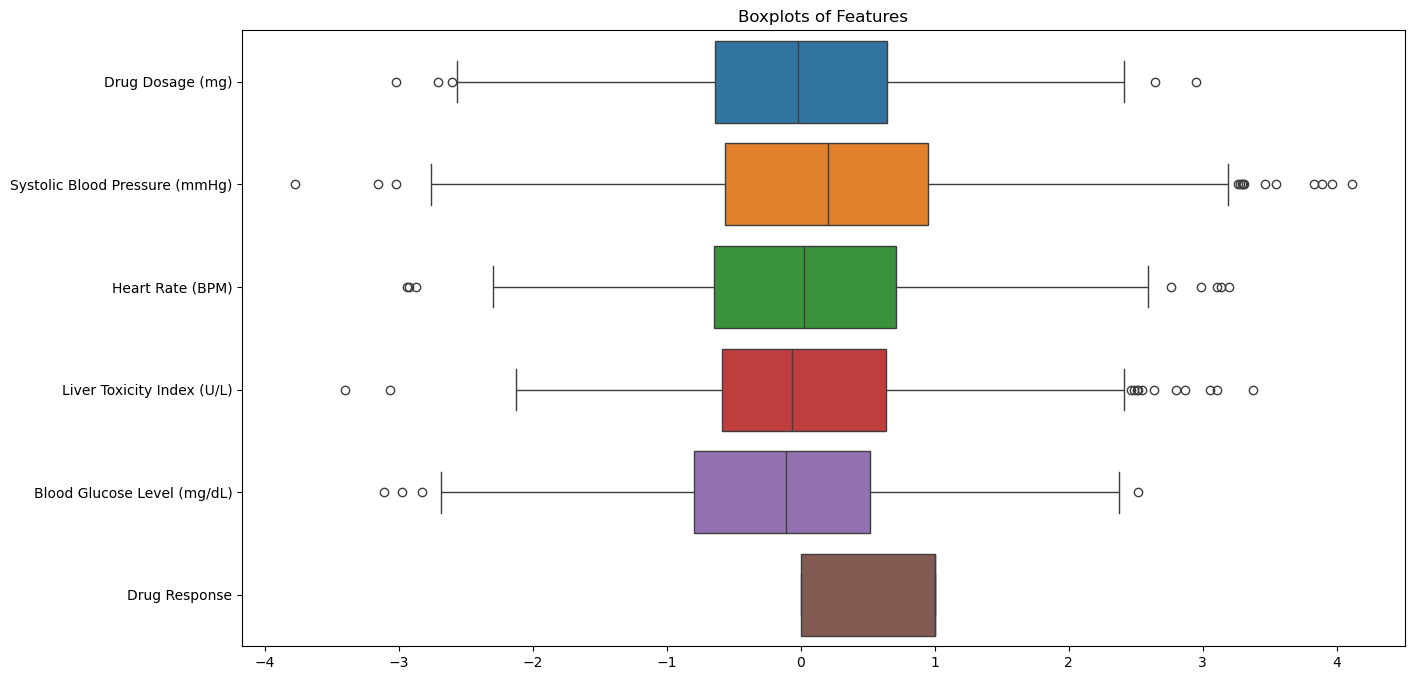

In [66]:
# Boxplots to check outliers
plt.figure(figsize=(15,8))
sns.boxplot(data=df, orient="h")
plt.title("Boxplots of Features")
plt.show()

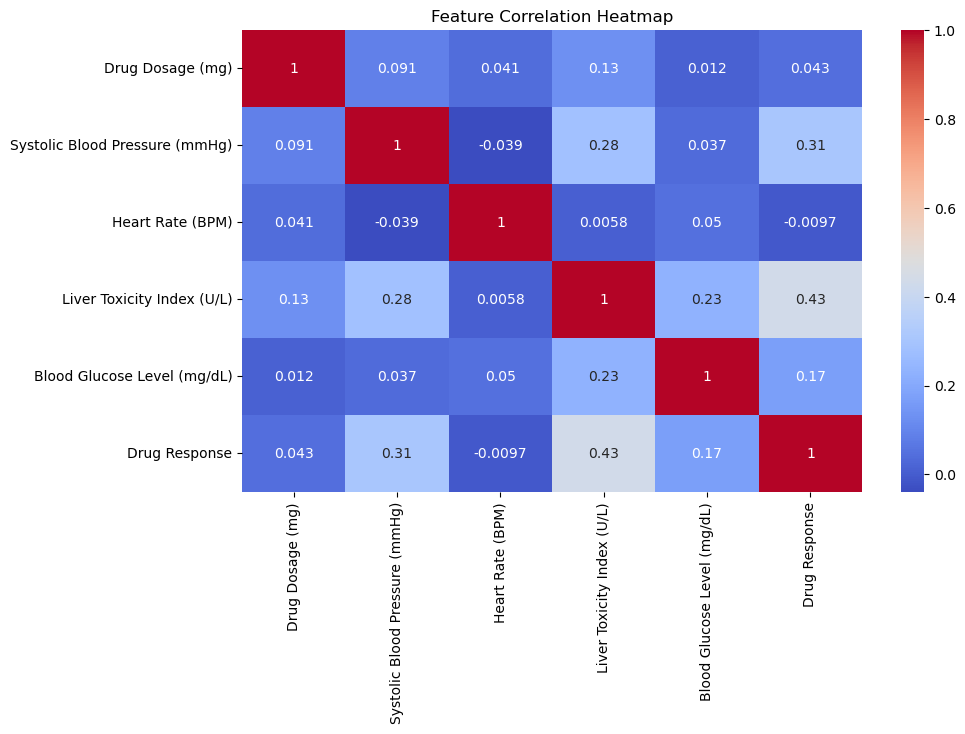

In [67]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


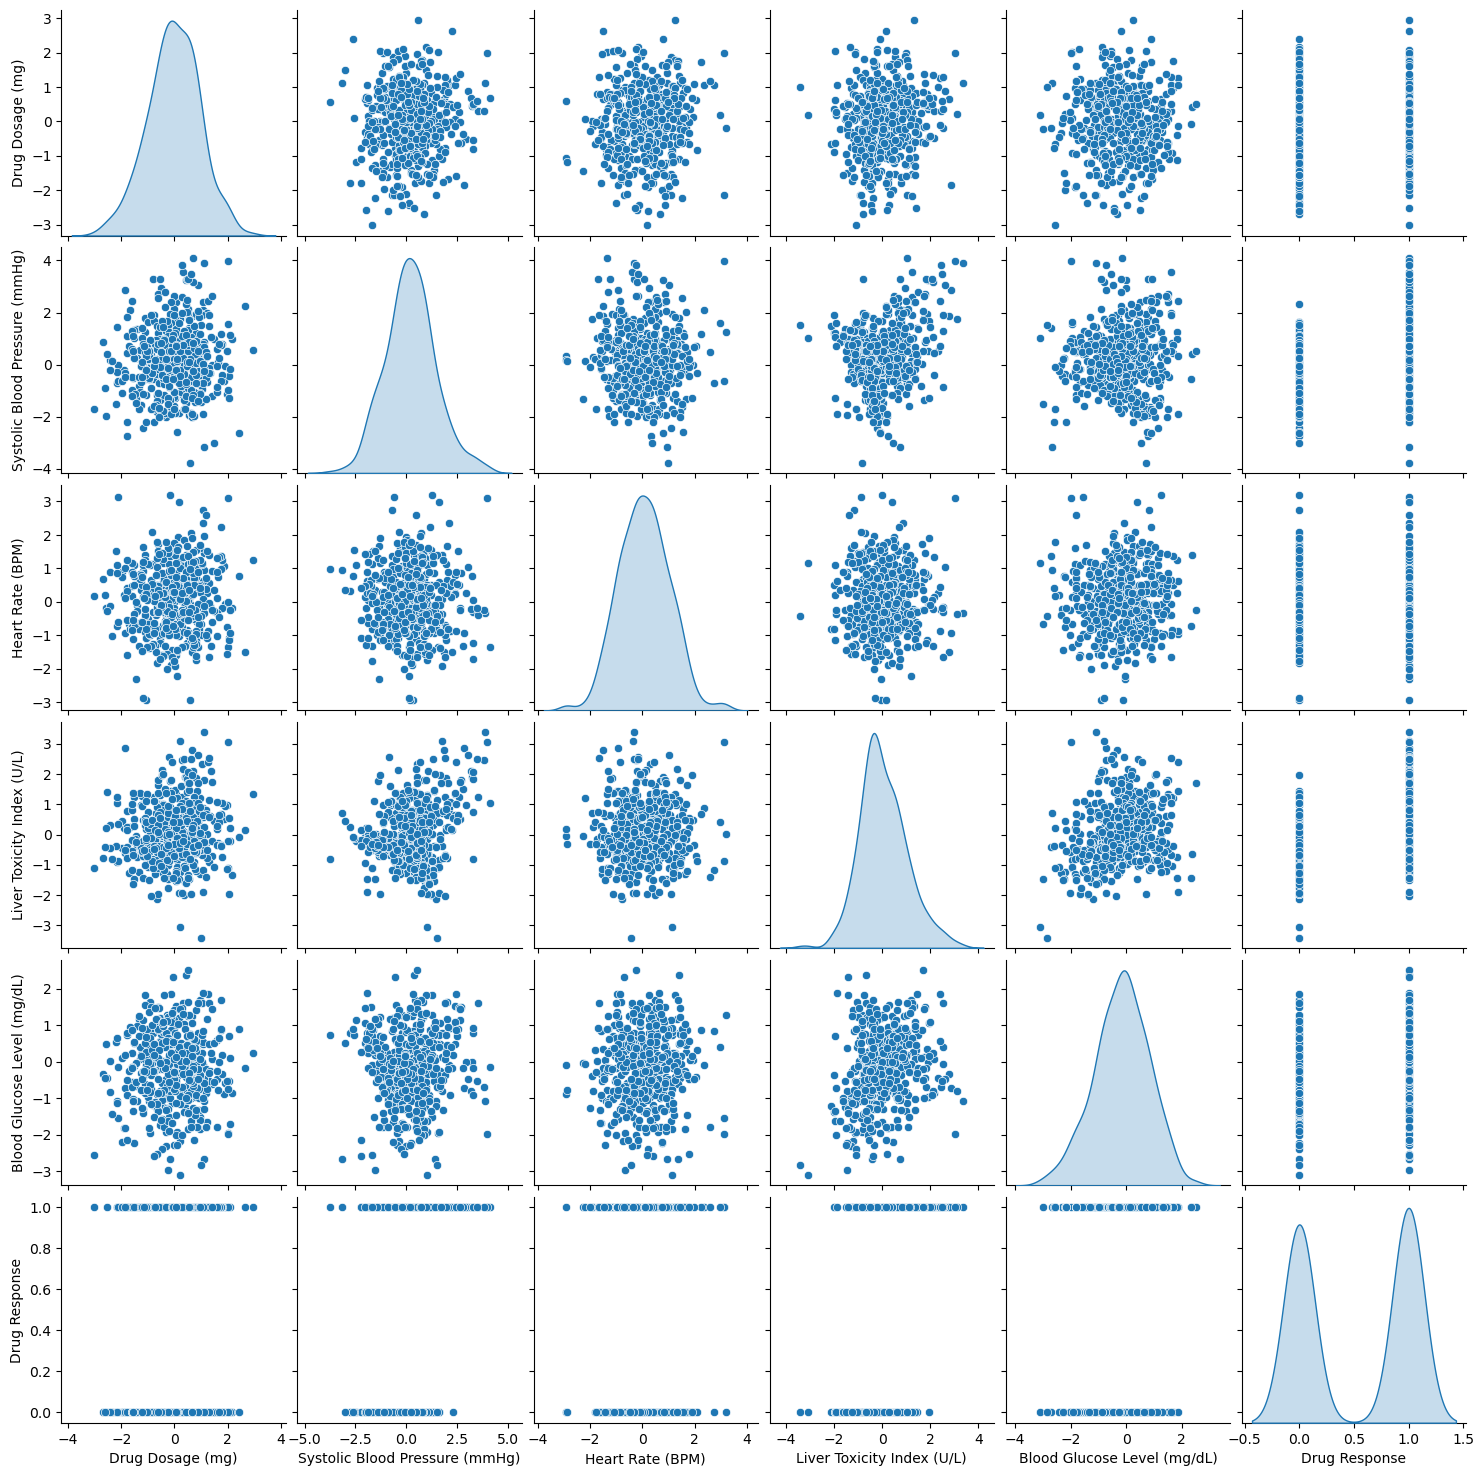

In [68]:
# Pairplot
sns.pairplot(df, diag_kind='kde')
plt.show()

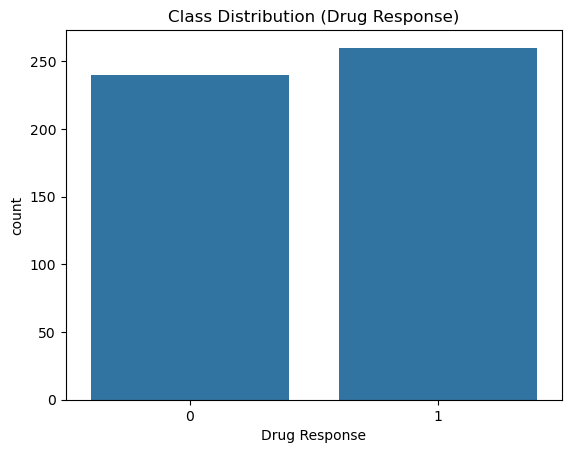

In [69]:
# Class distribution
sns.countplot(x=y)
plt.title("Class Distribution (Drug Response)")
plt.show()

#### SVM Implementation

In [70]:
# Basic SVM model
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)

In [78]:
# Evaluation
print("SVM with Linear Kernel")
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))
print("Classification Report:\n", classification_report(y_test, y_pred_linear))

SVM with Linear Kernel
Accuracy: 0.78
Confusion Matrix:
 [[36  8]
 [14 42]]
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



#### Visualization of SVM Results

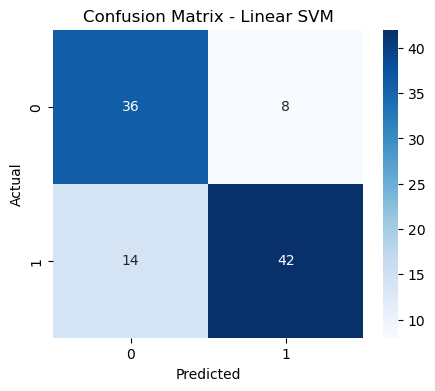

In [72]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_linear), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

####  Parameter Tuning and Optimization

In [73]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'poly', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Accuracy: 0.7300000000000001


In [74]:
# Evaluate optimized model
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print("\n=== Optimized SVM Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Classification Report:\n", classification_report(y_test, y_pred_best))


=== Optimized SVM Results ===
Accuracy: 0.84
Confusion Matrix:
 [[37  7]
 [ 9 47]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.84      0.82        44
           1       0.87      0.84      0.85        56

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



#### Comparison and Analysis

In [75]:
kernels = ['linear', 'poly', 'rbf']
results = {}

for k in kernels:
    svm_model = SVC(kernel=k, C=1, gamma='scale', random_state=42)
    svm_model.fit(X_train_scaled, y_train)
    y_pred = svm_model.predict(X_test_scaled)
    results[k] = accuracy_score(y_test, y_pred)


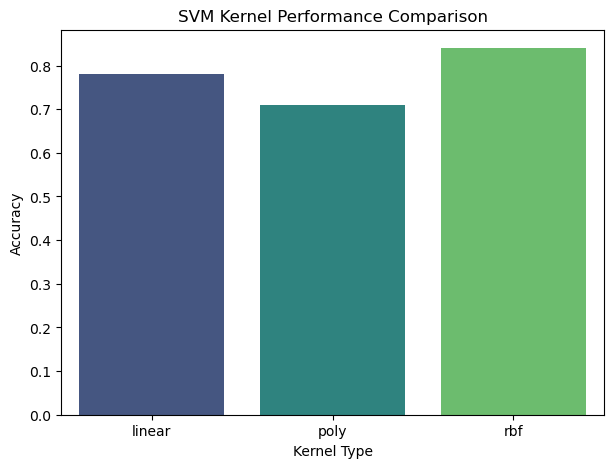

In [76]:
# Plot comparison
plt.figure(figsize=(7,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")
plt.title("SVM Kernel Performance Comparison")
plt.xlabel("Kernel Type")
plt.ylabel("Accuracy")
plt.show()

In [77]:
print("Kernel Performance Comparison\n")
for k, v in results.items():
    print(f"{k} Kernel Accuracy: {v:.4f}")

Kernel Performance Comparison

linear Kernel Accuracy: 0.7800
poly Kernel Accuracy: 0.7100
rbf Kernel Accuracy: 0.8400


#### Strengths, Weaknesses & Insights

##### SVM Strengths:
- Works well for both linear and non-linear data (using kernel trick)
- Effective in high-dimensional spaces
- Robust to overfitting when tuned properly

##### SVM Weaknesses:
- Computationally expensive for large datasets
- Requires feature scaling
- Parameter tuning (C, kernel, gamma) can be tricky

##### Practical Implications:
- SVM can be used in clinical trials to predict early drug response
- Helps pharmaceutical researchers identify patient groups who benefit most
- Supports personalized medicine initiatives by predicting drug efficacy efficiently

                                    Submitted by:  Meghana C Varghese